<a href="https://colab.research.google.com/github/NeuralDataMind/JAX/blob/main/JAX_Equinox_and_Optax.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [39]:
import jax
import jax.numpy as jnp
import equinox as eqx
import optax

import matplotlib.pyplot as plt
from typing import List

In [40]:
N_SAMPLES = 200
LAYERS = [1, 10, 10, 10, 1]
LEARNING_RATE = 0.1
N_EPOCHS = 30_000

In [41]:
key = jax.random.PRNGKey(0)

In [42]:
key, xkey, ynoisekey = jax.random.split(key, 3)

In [43]:
x_samples = jax.random.uniform(xkey, (N_SAMPLES, 1), minval = 0, maxval = 2 * jnp.pi)
y_samples = jnp.sin(x_samples) + jax.random.normal(ynoisekey, (N_SAMPLES, 1)) * 0.3

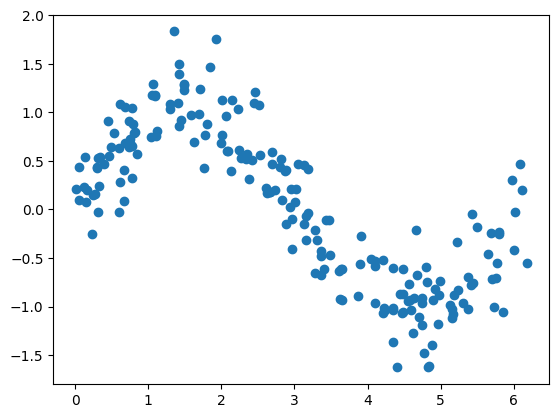

In [44]:
plt.scatter(x_samples, y_samples)

In [45]:
class SimpleNN(eqx.Module):
    layers: List[eqx.nn.Linear]

    def __init__(self, layer_size, key):
        self.layers = []

        for (fan_in, fan_out) in zip(layer_size[:-1], layer_size[1:]):
            key, subkey = jax.random.split(key)
            self.layers.append(
                 eqx.nn.Linear(fan_in, fan_out, use_bias = True, key = subkey)
            )

    def __call__(self, x):
        a = x

        for layer in self.layers[:-1]:
            a = jax.nn.sigmoid(layer(a))

        a = self.layers[-1](a)

        return a

In [46]:
model = SimpleNN(LAYERS, key = key)

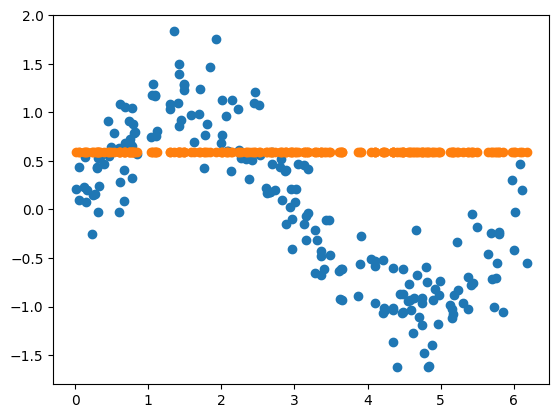

In [47]:
plt.scatter(x_samples, y_samples)
plt.scatter(x_samples, jax.vmap(model)(y_samples))

In [48]:
def model_to_loss(m, x, y):
    prediction = jax.vmap(m)(x)
    delta = prediction - y
    loss = jnp.mean(delta**2)

    return loss

In [49]:
model_to_loss(model, x_samples, y_samples)

Array(0.96348274, dtype=float32)

In [50]:
model_to_loss_and_grad = eqx.filter_value_and_grad(model_to_loss)

In [51]:
model_to_loss_and_grad(model, x_samples, y_samples)

(Array(0.96348274, dtype=float32),
 SimpleNN(
   layers=[
     Linear(
       weight=f32[10,1],
       bias=f32[10],
       in_features=1,
       out_features=10,
       use_bias=True
     ),
     Linear(
       weight=f32[10,10],
       bias=f32[10],
       in_features=10,
       out_features=10,
       use_bias=True
     ),
     Linear(
       weight=f32[10,10],
       bias=f32[10],
       in_features=10,
       out_features=10,
       use_bias=True
     ),
     Linear(
       weight=f32[1,10],
       bias=f32[1],
       in_features=10,
       out_features=1,
       use_bias=True
     )
   ]
 ))

In [52]:
opt = optax.sgd(LEARNING_RATE)
opt_state = opt.init(eqx.filter(model, eqx.is_array))

In [53]:
@eqx.filter_jit
def make_step(m, opt_s, x, y):
    loss, grad = model_to_loss_and_grad(m, x, y)
    updates, opt_s = opt.update(grad, opt_s, m)
    m = eqx.apply_updates(m, updates)

    return m, opt_s, loss

In [54]:
loss_history = []

for epoch in range(N_EPOCHS):
    model, opt_state, loss = make_step(model, opt_state, x_samples, y_samples
                             )

    loss_history.append(loss)

    if epoch % 100 == 0:
        print(f"Epoch: {epoch} loss: {loss}")

Epoch: 0 loss: 0.9634827375411987
Epoch: 100 loss: 0.6315845251083374
Epoch: 200 loss: 0.6309247612953186
Epoch: 300 loss: 0.6300976276397705
Epoch: 400 loss: 0.6288855671882629
Epoch: 500 loss: 0.626867413520813
Epoch: 600 loss: 0.6230676174163818
Epoch: 700 loss: 0.6147803068161011
Epoch: 800 loss: 0.5927037000656128
Epoch: 900 loss: 0.5206020474433899
Epoch: 1000 loss: 0.35166120529174805
Epoch: 1100 loss: 0.26933273673057556
Epoch: 1200 loss: 0.2524050772190094
Epoch: 1300 loss: 0.2451135367155075
Epoch: 1400 loss: 0.23967589437961578
Epoch: 1500 loss: 0.2347746640443802
Epoch: 1600 loss: 0.2301228642463684
Epoch: 1700 loss: 0.22565513849258423
Epoch: 1800 loss: 0.22136548161506653
Epoch: 1900 loss: 0.21726302802562714
Epoch: 2000 loss: 0.21335798501968384
Epoch: 2100 loss: 0.2096572071313858
Epoch: 2200 loss: 0.20616281032562256
Epoch: 2300 loss: 0.20287272334098816
Epoch: 2400 loss: 0.19978110492229462
Epoch: 2500 loss: 0.1968793421983719
Epoch: 2600 loss: 0.1941569447517395
Epoc

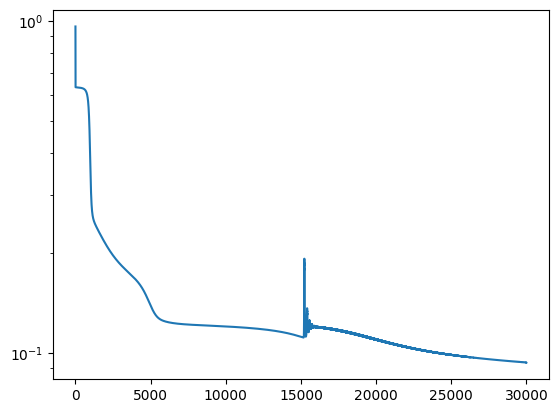

In [55]:
plt.plot(loss_history)
plt.yscale("log")

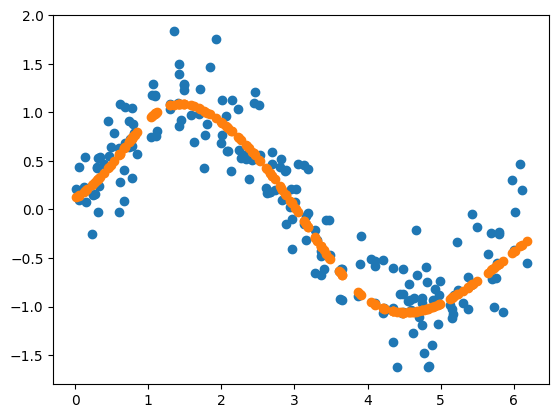

In [56]:
plt.scatter(x_samples, y_samples)
plt.scatter(x_samples, jax.vmap(model)(x_samples))